# Questão 3

Comparação entre compressão por DCT e por DFT/FFT para o áudio `handel.wav`,
preservando `99.5%`, `99.0%`, `90.0%`, `75.0%` e `50.0%` da energia.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy.fft import dct, idct, fft, ifft

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()

def find_repo_root(start_path):
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'data').exists() and (candidate / 'pratica_4').exists():
            return candidate
    raise FileNotFoundError(
        'Repositorio nao encontrado. Execute o notebook dentro da pasta do projeto.'
    )

REPO_ROOT = find_repo_root(CWD)
DATA_DIR = REPO_ROOT / 'data'
AUDIO_PATH = DATA_DIR / 'handel.wav'


In [2]:
def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def to_float_mono(signal):
    signal = np.asarray(signal)
    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    return signal


def show_audio(signal, fs, label):
    signal = np.asarray(signal, dtype=np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    display(Audio(signal, rate=fs))
    print(label)


def select_by_energy(coeffs, keep_energy):
    coeffs = np.asarray(coeffs)
    energy = np.abs(coeffs) ** 2
    flat_energy = energy.ravel()
    order = np.argsort(flat_energy)[::-1]
    cumulative = np.cumsum(flat_energy[order])
    total_energy = cumulative[-1]
    threshold = keep_energy * total_energy
    keep_count = int(np.searchsorted(cumulative, threshold, side='left')) + 1

    mask = np.zeros(coeffs.size, dtype=bool)
    mask[order[:keep_count]] = True
    mask = mask.reshape(coeffs.shape)

    compressed = np.zeros_like(coeffs)
    compressed[mask] = coeffs[mask]
    retained = float(np.sum(np.abs(compressed) ** 2) / total_energy)
    return compressed, keep_count, retained


def compress_audio_dct(signal, keep_energy):
    coeffs = dct(signal, norm='ortho')
    compressed, keep_count, retained = select_by_energy(coeffs, keep_energy)
    reconstructed = idct(compressed, norm='ortho')
    return reconstructed, keep_count, retained


def compress_audio_fft(signal, keep_energy):
    coeffs = fft(signal)
    compressed, keep_count, retained = select_by_energy(coeffs, keep_energy)
    reconstructed = np.real(ifft(compressed))
    return reconstructed, keep_count, retained



In [3]:
fs, raw_signal = wavfile.read(AUDIO_PATH)
signal = to_float_mono(raw_signal)

print(f'Taxa de amostragem: {fs} Hz')
print(f'Amostras: {len(signal)}')
print(f'Duracao: {len(signal) / fs:.2f} s')

show_audio(signal, fs, 'Audio original: handel.wav')


Taxa de amostragem: 8192 Hz
Amostras: 73113
Duracao: 8.92 s


Audio original: handel.wav


In [4]:
keep_levels = [0.995, 0.99, 0.90, 0.75, 0.50]
dct_results = {}
fft_results = {}
rows = []

for keep in keep_levels:
    label = f'{keep * 100:.1f}%'
    dct_rec, dct_count, dct_energy = compress_audio_dct(signal, keep)
    fft_rec, fft_count, fft_energy = compress_audio_fft(signal, keep)

    dct_results[label] = dct_rec
    fft_results[label] = fft_rec

    rows.append(
        {
            'Energia': label,
            'Coeficientes DCT': dct_count,
            'Coeficientes FFT': fft_count,
            'MSE DCT': mse(signal, dct_rec),
            'MSE FFT': mse(signal, fft_rec),
        }
    )

display_rows(rows, float_digits=8)


Energia | Coeficientes DCT | Coeficientes FFT | MSE DCT    | MSE FFT   
--------+------------------+------------------+------------+-----------
99.5%   | 40702            | 48670            | 0.00030080 | 0.00030079
99.0%   | 33683            | 40986            | 0.00060162 | 0.00060155
90.0%   | 9038             | 11661            | 0.00601602 | 0.00601615
75.0%   | 3200             | 4325             | 0.01503845 | 0.01503943
50.0%   | 835              | 1170             | 0.03007397 | 0.03007461


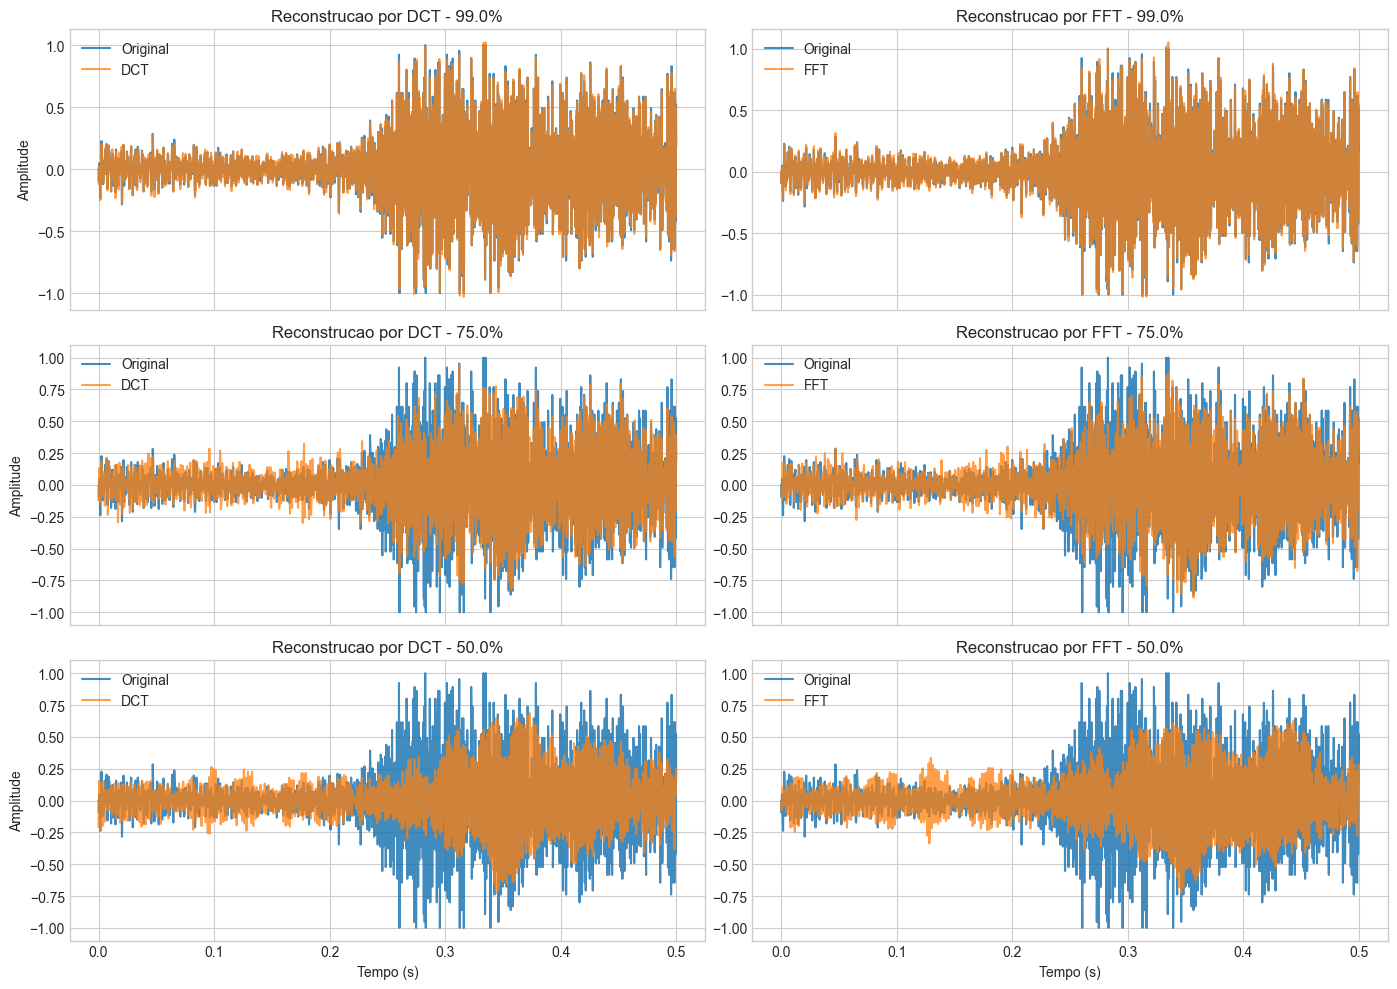

In [5]:
selected = ['99.0%', '75.0%', '50.0%']
fig, axes = plt.subplots(len(selected), 2, figsize=(14, 10), sharex=True)
time = np.arange(len(signal)) / fs
snippet = slice(0, min(len(signal), fs // 2))

for idx, label in enumerate(selected):
    axes[idx, 0].plot(time[snippet], signal[snippet], label='Original', alpha=0.85)
    axes[idx, 0].plot(time[snippet], dct_results[label][snippet], label='DCT', alpha=0.75)
    axes[idx, 0].set_title(f'Reconstrucao por DCT - {label}')
    axes[idx, 0].set_ylabel('Amplitude')
    axes[idx, 0].legend()

    axes[idx, 1].plot(time[snippet], signal[snippet], label='Original', alpha=0.85)
    axes[idx, 1].plot(time[snippet], fft_results[label][snippet], label='FFT', alpha=0.75)
    axes[idx, 1].set_title(f'Reconstrucao por FFT - {label}')
    axes[idx, 1].legend()

axes[-1, 0].set_xlabel('Tempo (s)')
axes[-1, 1].set_xlabel('Tempo (s)')
plt.tight_layout()
plt.show()


In [6]:
for label in ['99.0%', '75.0%', '50.0%']:
    show_audio(dct_results[label], fs, f'DCT com {label} de energia')
    show_audio(fft_results[label], fs, f'FFT com {label} de energia')


DCT com 99.0% de energia


FFT com 99.0% de energia


DCT com 75.0% de energia


FFT com 75.0% de energia


DCT com 50.0% de energia


FFT com 50.0% de energia


## Comentários

- A DCT costuma concentrar energia em menos coeficientes do que a FFT para esse tipo de áudio.
- Isso aparece tanto na contagem de coeficientes quanto no erro médio quadrático.
- Em taxas mais agressivas de compressão, a diferença perceptual entre DCT e FFT tende a ficar mais evidente.
